<a href="https://colab.research.google.com/github/OlajideFemi/Carbon-Footprint/blob/main/MongoDB_Create_Read_Update_Delete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# PRODUCTION:
import os
from dotenv import load_dotenv

load_dotenv()
MONGO_URI = os.getenv("MONGODB_URI")

In [ ]:
# More aggregation:
pipeline = [
    {"$match": {"exp": {"$gte": 2}}},  # Filter first (performance!)
    {"$group": {
        "_id": "$role",
        "avg_experience": {"$avg": "$exp"},
        "total_employees": {"$sum": 1}
    }},
    {"$sort": {"avg_experience": -1}}
]

In [ ]:
pipeline = [
    {"$group": {
        "_id": "$role",
        "avg_salary": {"$avg": "$salary"}
    }},
    {"$match": {"avg_salary": {"$gt": 42000}}}
]

results = list(col.aggregate(pipeline))
print(results)
# [{"_id": "Engineer", "avg_salary": 60000}]

In [ ]:
from pymongo import MongoClient
from pymongo.server_api import ServerApi

# Replace with your real Atlas connection string
MONGO_URI = "mongodb+srv://<username>:<password>@<cluster-url>/?retryWrites=true&w=majority"

client = MongoClient(MONGO_URI, server_api=ServerApi("1"))

try:
    client.admin.command("ping")
    print("Connected to MongoDB Atlas successfully.")
except Exception as e:
    print("Connection failed:", e)

In [ ]:
from pymongo import MongoClient
from pymongo.server_api import ServerApi

MONGO_URI = "mongodb+srv://<username>:<password>@<cluster-url>/?retryWrites=true&w=majority"

client = MongoClient(MONGO_URI, server_api=ServerApi("1"))

# database and collection
db = client["training_db"]
collection = db["employees"]

# optional: clear old demo data
collection.delete_many({})

# ----------------
# CREATE
# ----------------
one_result = collection.insert_one({
    "name": "Oluwafemi",
    "role": "Data Analyst",
    "skills": ["Python", "Power BI", "SQL"],
    "years_experience": 3
})
print("Inserted one ID:", one_result.inserted_id)

many_result = collection.insert_many([
    {
        "name": "Ada",
        "role": "Backend Developer",
        "skills": ["Python", "MongoDB"],
        "years_experience": 2
    },
    {
        "name": "Tunde",
        "role": "Data Engineer",
        "skills": ["SQL", "ETL", "MongoDB"],
        "years_experience": 4
    }
])
print("Inserted many IDs:", many_result.inserted_ids)

# ----------------
# READ
# ----------------
print("\nAll documents:")
for doc in collection.find():
    print(doc)

print("\nOne document where role is Data Analyst:")
print(collection.find_one({"role": "Data Analyst"}))

print("\nPeople with MongoDB skill:")
for doc in collection.find({"skills": "MongoDB"}):
    print(doc)

# ----------------
# UPDATE
# ----------------
update_one_result = collection.update_one(
    {"name": "Ada"},
    {"$set": {"years_experience": 3}}
)
print("\nMatched:", update_one_result.matched_count)
print("Modified:", update_one_result.modified_count)

update_many_result = collection.update_many(
    {"skills": "MongoDB"},
    {"$set": {"tooling": "Atlas"}}
)
print("Updated many:", update_many_result.modified_count)

# ----------------
# DELETE
# ----------------
delete_one_result = collection.delete_one({"name": "Tunde"})
print("\nDeleted one:", delete_one_result.deleted_count)

delete_many_result = collection.delete_many({"tooling": "Atlas"})
print("Deleted many:", delete_many_result.deleted_count)

print("\nRemaining documents:")
for doc in collection.find():
    print(doc)

In [ ]:
import os
from pymongo import MongoClient

client = MongoClient(os.getenv("MONGO_URI"))

In [ ]:
#Bash
#export MONGO_URI="mongodb+srv://<username>:<password>@<cluster-url>/?retryWrites=true&w=majority"

In [ ]:
#PowerShell
#$env:MONGO_URI="mongodb+srv://<username>:<password>@<cluster-url>/?retryWrites=true&w=majority"

In [1]:
#save as .json

{
  "name": "Mechanical Keyboard",
  "price": 89.99,
  "category": "Electronics",
  "stock": 15,
  "features": ["RGB", "Mechanical switches", "Wired"]
}

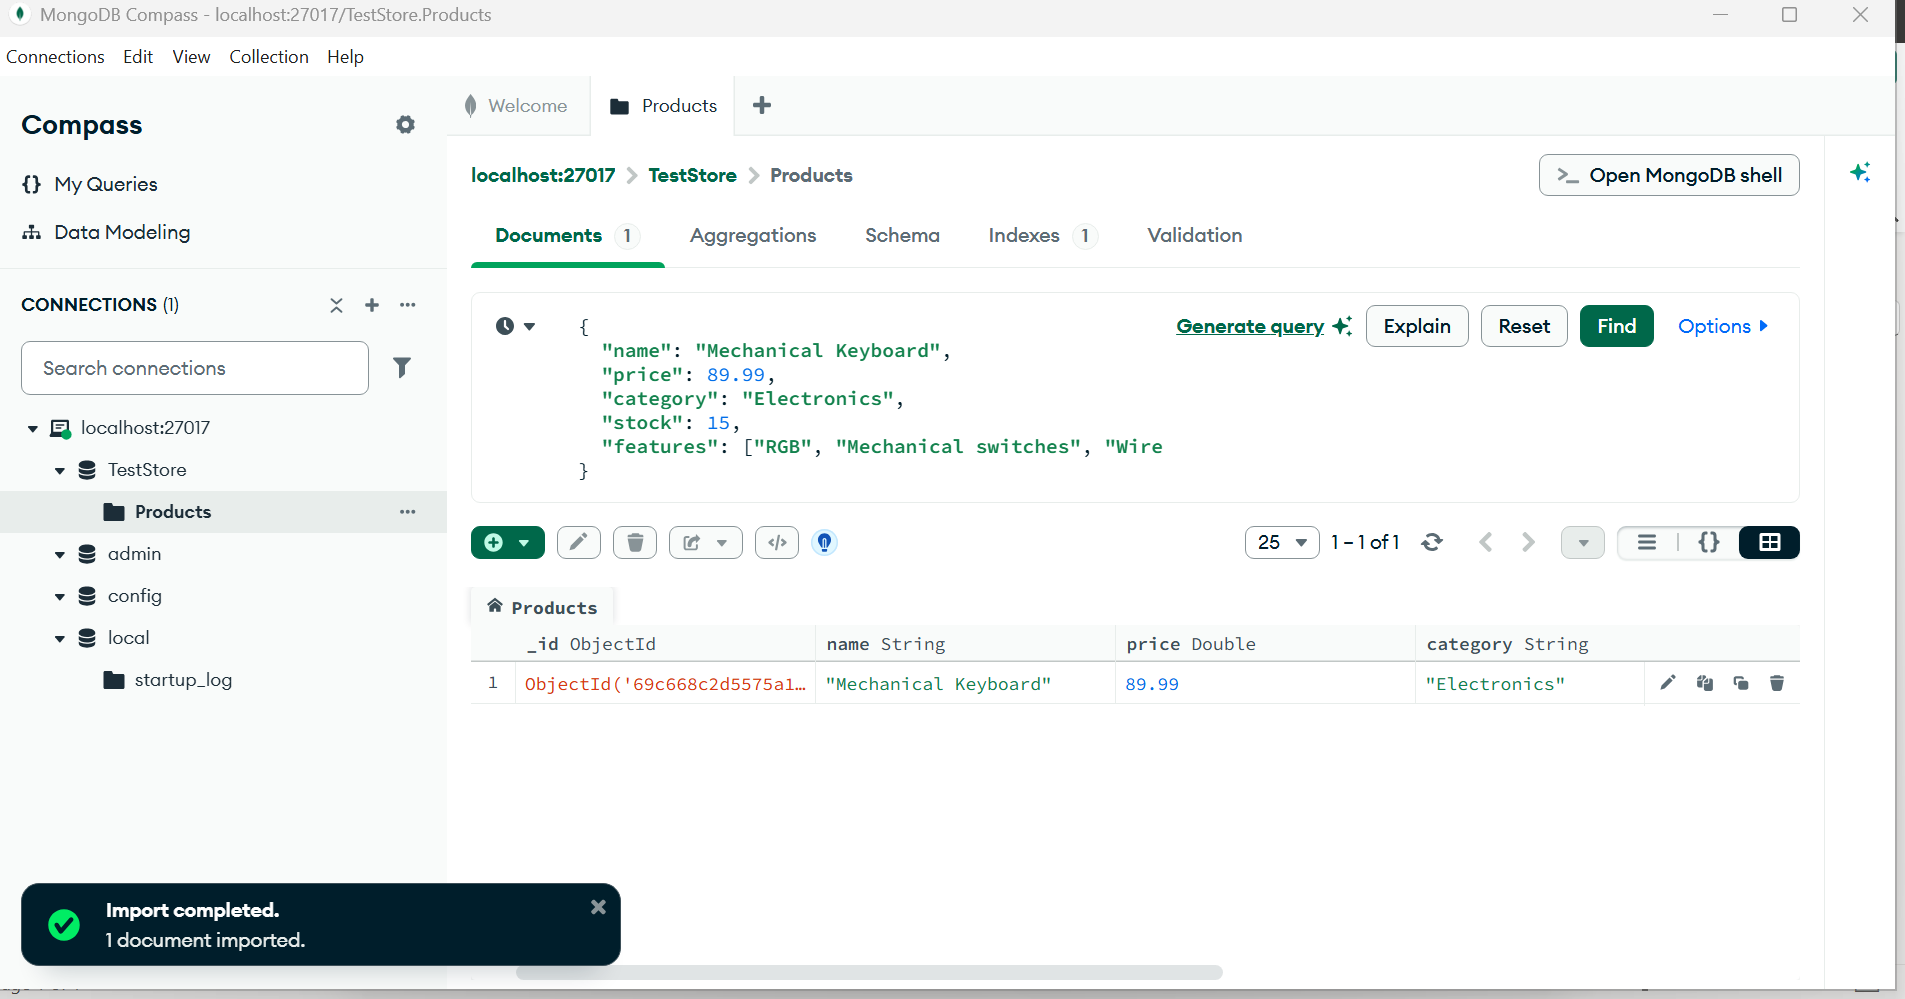

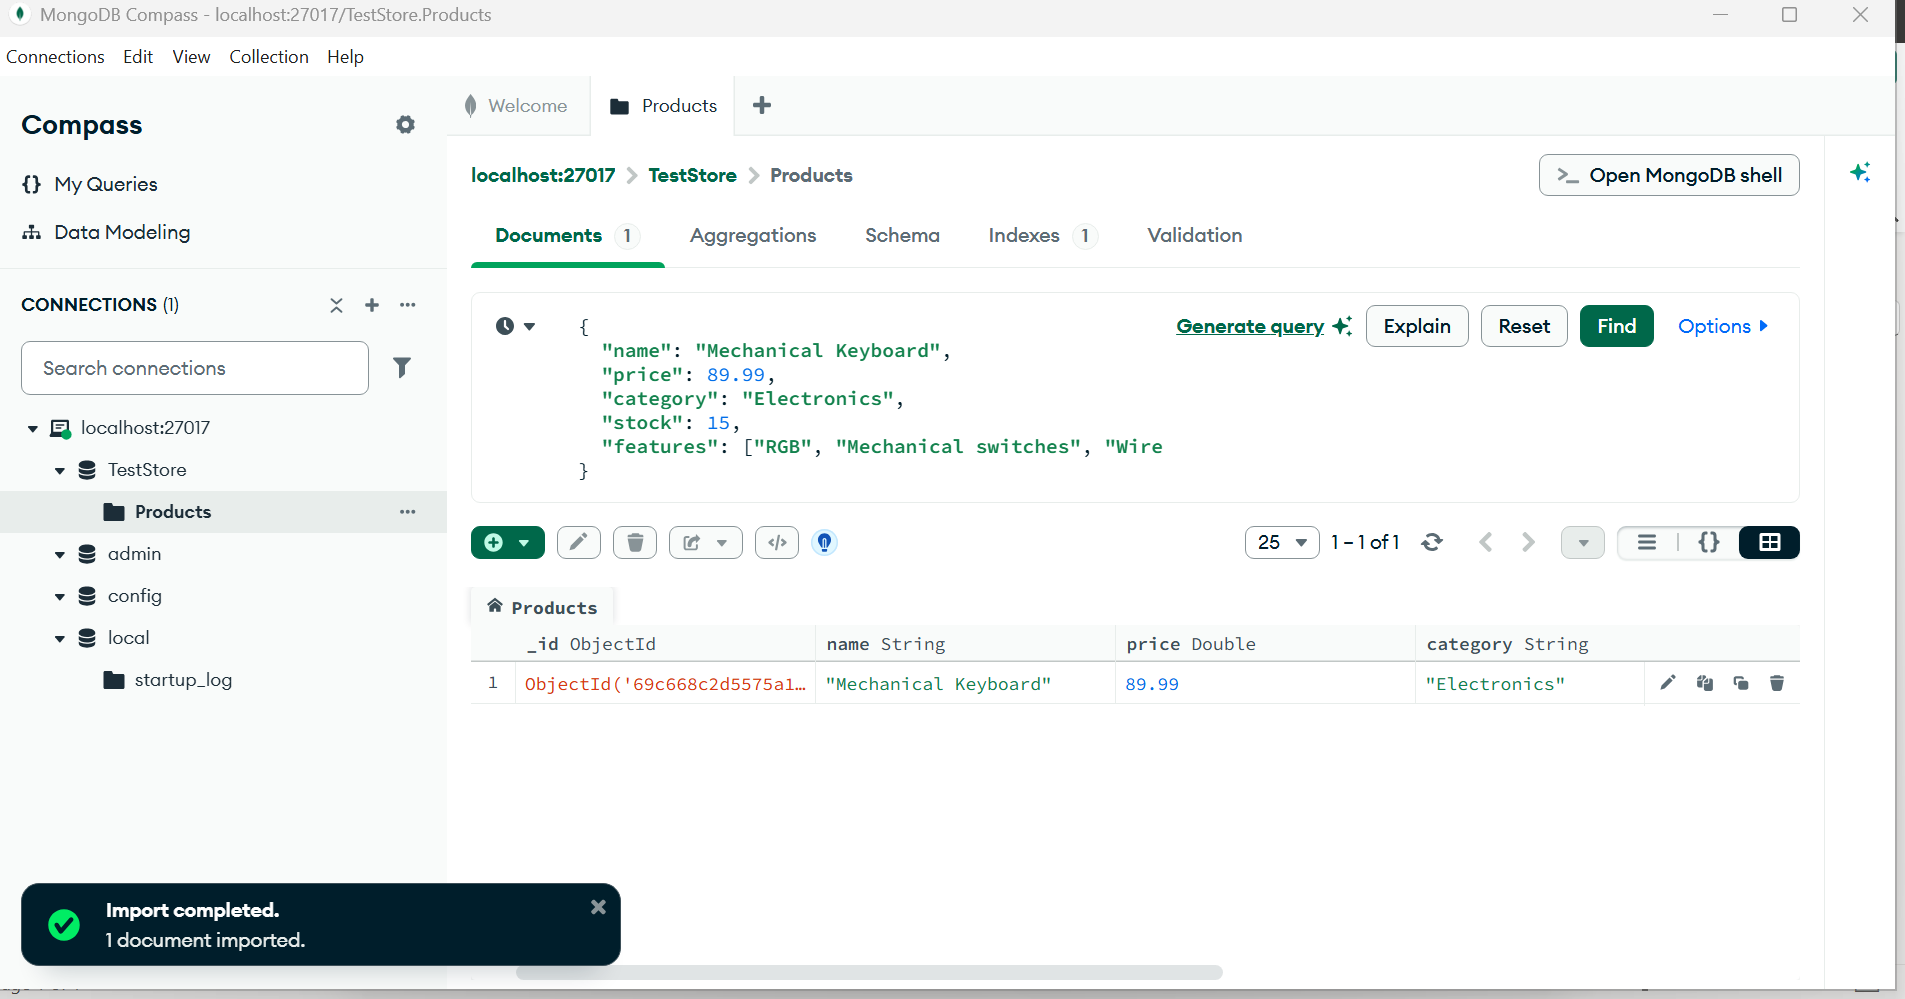

In [ ]:
[
	{
        "name": "Wireless Mouse",
        "price": 29.99,
        "category": "Electronics",
        "stock": 42,
        "features": ["Wireless", "Ergonomic", "16000 DPI"],
        "rating": 4.3,
        "supplier": "LogiTech Solutions",
        "release_date": "2023-11-20"
    },
    {
        "name": "4K Monitor 27 inch",
        "price": 349.99,
        "category": "Electronics",
        "stock": 8,
        "features": ["4K", "IPS Panel", "HDR"],
        "rating": 4.7,
        "supplier": "DisplayTech",
        "release_date": "2024-02-01"
    },
    {
        "name": "Noise Cancelling Headphones",
        "price": 199.99,
        "category": "Electronics",
        "stock": 23,
        "features": ["Bluetooth 5.0", "ANC", "30hr battery"],
        "rating": 4.6,
        "supplier": "AudioPro",
        "release_date": "2023-10-10"
    },
    {
        "name": "USB-C Hub",
        "price": 45.99,
        "category": "Electronics",
        "stock": 67,
        "features": ["7 ports", "4K HDMI", "100W charging"],
        "rating": 4.2,
        "supplier": "ConnectPlus",
        "release_date": "2024-01-05"
    },
    {
        "name": "Ergonomic Office Chair",
        "price": 299.99,
        "category": "Office",
        "stock": 12,
        "features": ["Adjustable lumbar", "Mesh back", "Headrest"],
        "rating": 4.8,
        "supplier": "ComfortWorks",
        "release_date": "2023-09-15"
    },
    {
        "name": "Standing Desk",
        "price": 399.99,
        "category": "Office",
        "stock": 5,
        "features": ["Electric height adjustment", "Memory presets"],
        "rating": 4.9,
        "supplier": "DeskMaster",
        "release_date": "2024-02-10"
    },
    {
        "name": "Notebook Set",
        "price": 12.99,
        "category": "Office",
        "stock": 150,
        "features": ["Hardcover", "120 pages", "Set of 3"],
        "rating": 4.0,
        "supplier": "PaperCo",
        "release_date": "2023-12-01"
    },
    {
        "name": "Desk Lamp with Wireless Charger",
        "price": 79.99,
        "category": "Office",
        "stock": 34,
        "features": ["LED", "Wireless charging", "Dimmable"],
        "rating": 4.4,
        "supplier": "BrightIdeas",
        "release_date": "2024-01-20"
    },
    {
        "name": "Laptop Sleeve",
        "price": 24.99,
        "category": "Accessories",
        "stock": 89,
        "features": ["Water resistant", "Fits 15.6 inch", "Neoprene"],
        "rating": 4.1,
        "supplier": "SafeGuard",
        "release_date": "2023-11-05"
    },
    {
        "name": "Cable Management Kit",
        "price": 18.99,
        "category": "Accessories",
        "stock": 210,
        "features": ["Zip ties", "Cable clips", "Velcro straps"],
        "rating": 4.3,
        "supplier": "CablePro",
        "release_date": "2024-01-25"
    },
    {
        "name": "Laptop Stand",
        "price": 34.99,
        "category": "Accessories",
        "stock": 56,
        "features": ["Aluminum", "Foldable", "Ergonomic angle"],
        "rating": 4.5,
        "supplier": "RiseUp",
        "release_date": "2023-12-15"
    },
    {
        "name": "Webcam 1080p",
        "price": 59.99,
        "category": "Electronics",
        "stock": 28,
        "features": ["1080p", "Auto-focus", "Privacy cover"],
        "rating": 4.4,
        "supplier": "CamTech",
        "release_date": "2024-02-05"
    },
    {
        "name": "Mechanical Keyboard - Limited Edition",
        "price": 189.99,
        "category": "Electronics",
        "stock": 3,
        "features": ["RGB", "Custom switches", "Aluminum case", "Wireless"],
        "rating": 4.9,
        "supplier": "TechGear Inc",
        "release_date": "2024-02-14"
    },
    {
        "name": "Monitor Arm Dual Mount",
        "price": 89.99,
        "category": "Office",
        "stock": 18,
        "features": ["Gas spring", "VESA compatible", "Cable management"],
        "rating": 4.6,
        "supplier": "MountPro",
        "release_date": "2023-10-30"
    }
]

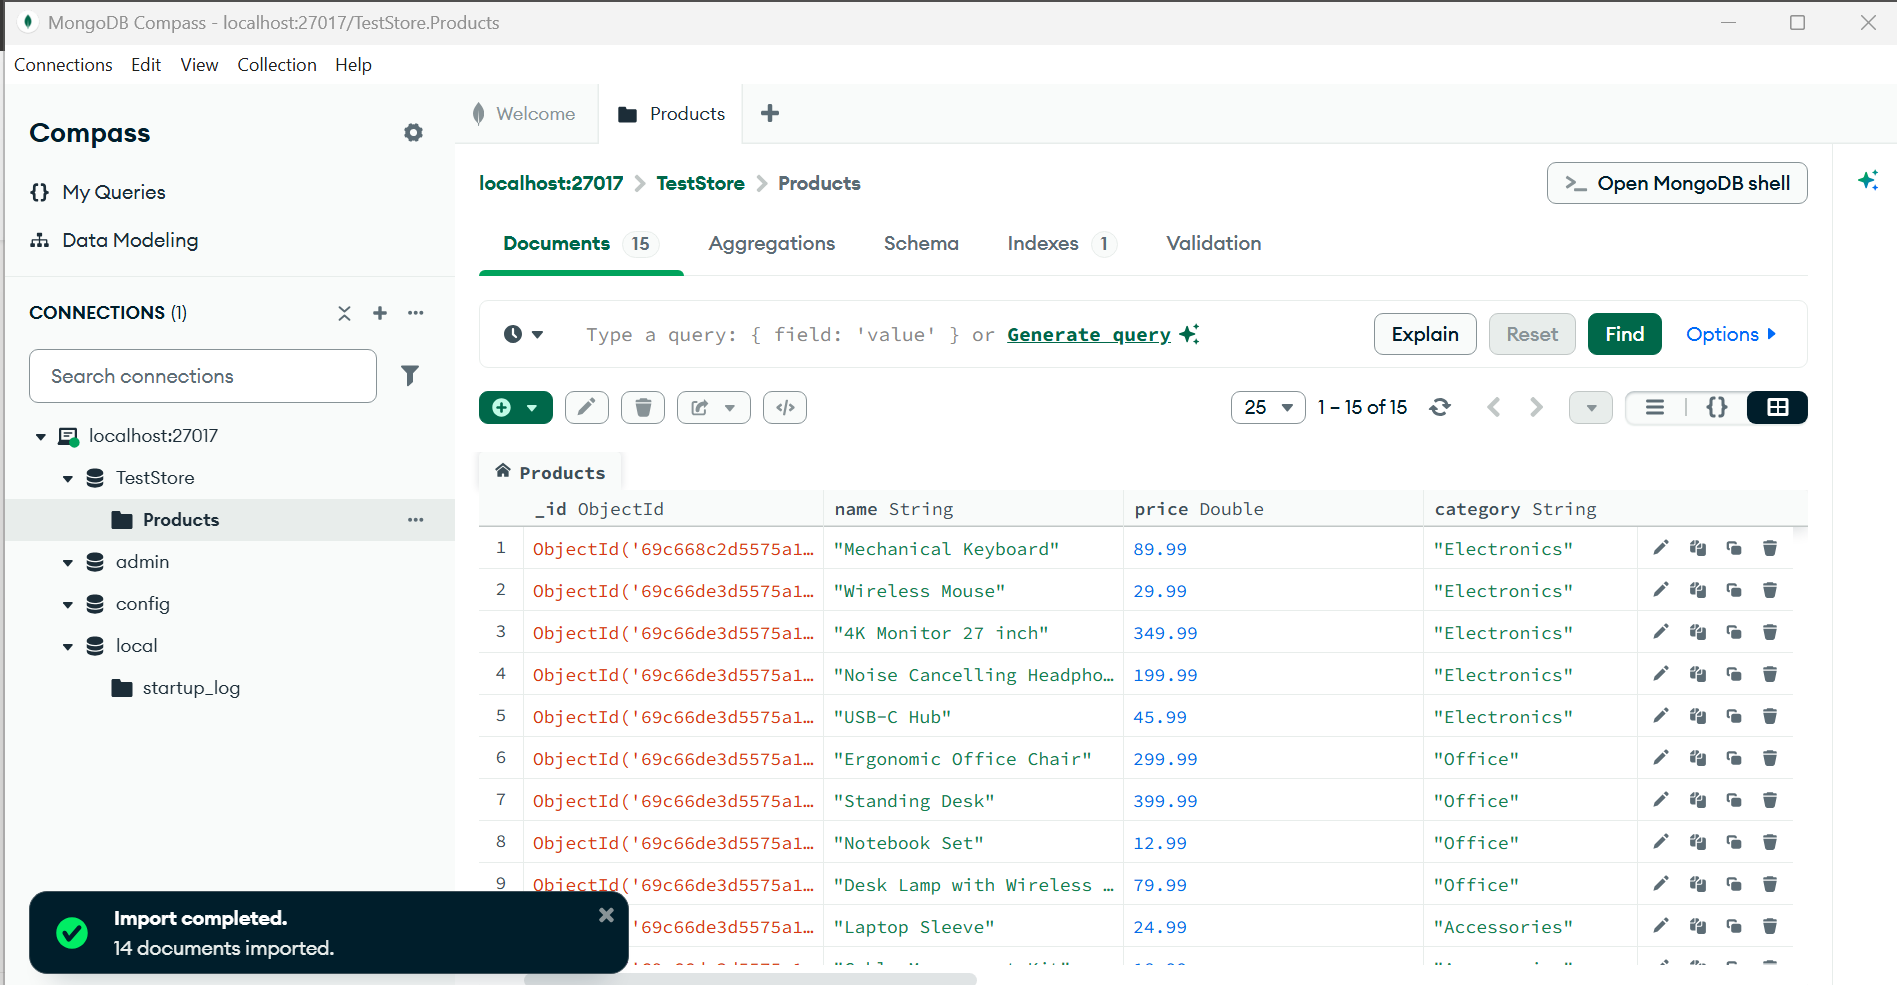